In [1]:
import arviz as az
import pandas as pd
import numpy as np
import pymc as pm
import bambi as bmb
import xarray as xr
import random
import os
from sklearn.preprocessing import LabelEncoder

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format = 'retina'
sns.set_context('paper')
sns.set_style('ticks')
plt.rc("axes.spines", top=False, right=False)
with matplotlib.style.context('arviz-doc'):
    az_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
sns.set_palette(az_colors)

def origo(ax=None):
    if ax is None:
        ax = plt.gca()
    x, y = ax.get_xlim(), ax.get_ylim()
    minx, maxx = min(x), max(x)
    miny, maxy = min(y), max(y)
    plt.ylim(min(0, miny), max(0, maxy))
    plt.xlim(min(0, minx), max(0, maxx))

In [2]:
# scale = 0.35
# d = dict([(k, v*scale) for (k, v) in sns.plotting_context().items() if v is not None])
# d['figure.figsize'] = [1.8, 1.3]
# matplotlib.rcParams.update(d)
# make context for with statement:
# #matplotlib.style.context(d)

In [3]:
# plt.plot(np.random.random(10), np.random.random(10)-10)
# origo()

In [4]:
#Disable annoying "UserWarning: The figure layout has changed to tight" message
import warnings
warnings.filterwarnings('ignore', category=UserWarning
                        # , module='seaborn'
                       )
warnings.filterwarnings('ignore', category=FutureWarning,
                        # module='matplotlib'
                       )

# Read in data

Filter based on callability and remove X chromosome and adjust for missing coverage by extrapolating

In [5]:
data = pd.read_csv('Reduced_Ne_Pi_recomb.csv')
#data.full_species.unique()

In [6]:
data = data[data['freq_mean']>0.7]
data = data[data['chr']!='chrX']
data['corrected_pi'] = data['PI']*data['freq_mean']
data['log_cm_per_mb'] = np.log1p(data.cm_per_mb)

In [7]:
selected_groups = ['Gorilla_gorilla', 'Chiropotes_albinasus', 'Saimiri_ustus']

In [8]:
# # subset data for testing
#data = data.loc[(data['chr'] == 'chr1') & (data.full_species.isin(['Gorilla_gorilla', 'Chiropotes_albinasus', 'Saimiri_ustus']))]
data.full_species.unique()

array(['Allenopithecus_nigroviridis', 'Allochrocebus_lhoesti',
       'Allochrocebus_preussi', 'Allochrocebus_solatus',
       'Alouatta_belzebul', 'Alouatta_caraya', 'Alouatta_discolor',
       'Alouatta_juara', 'Alouatta_macconnelli', 'Alouatta_nigerrima',
       'Alouatta_palliata', 'Alouatta_puruensis', 'Alouatta_seniculus',
       'Aotus_azarae', 'Aotus_griseimembra', 'Aotus_trivirgatus',
       'Aotus_vociferans', 'Arctocebus_calabarensis', 'Ateles_belzebuth',
       'Ateles_chamek', 'Ateles_geoffroyi', 'Ateles_marginatus',
       'Ateles_paniscus', 'Cacajao_ayresi', 'Cacajao_calvus',
       'Cacajao_hosomi', 'Cacajao_melanocephalus', 'Callimico_goeldii',
       'Callithrix_geoffroyi', 'Callithrix_jacchus', 'Callithrix_kuhlii',
       'Cebuella_niveiventris', 'Cebuella_pygmaea', 'Cebus_albifrons',
       'Cebus_olivaceus', 'Cebus_unicolor', 'Cercocebus_chrysogaster',
       'Cercocebus_lunulatus', 'Cercocebus_torquatus',
       'Cercopithecus_ascanius', 'Cercopithecus_cephus',
  

In [9]:
#data[['full_species', 'NE_MEAN']].drop_duplicates().sort_values(by='NE_MEAN').head(100)

In [10]:
data.head()

,Unnamed: 0,genus,species,full_species,MEAN,MEDIAN,NE_MEAN,NE_MEDIAN,freq_mean,cm_per_mb,chr,PI,corrected_pi,log_cm_per_mb
2,2,Allenopithecus,nigroviridis,Allenopithecus_nigroviridis,8.357479e-09,8.297569e-09,52454.392022,48795.239046,0.809708,0.032423,chr1,0.001810,0.001466,0.031909
3,3,Allenopithecus,nigroviridis,Allenopithecus_nigroviridis,8.357479e-09,8.297569e-09,52454.392022,48795.239046,0.716477,1.734505,chr1,0.002047,0.001466,1.005951
4,4,Allenopithecus,nigroviridis,Allenopithecus_nigroviridis,8.357479e-09,8.297569e-09,52454.392022,48795.239046,0.784308,1.056430,chr1,0.002565,0.002012,0.720971
5,5,Allenopithecus,nigroviridis,Allenopithecus_nigroviridis,8.357479e-09,8.297569e-09,52454.392022,48795.239046,0.747552,0.420616,chr1,0.001845,0.001379,0.351091
6,6,Allenopithecus,nigroviridis,Allenopithecus_nigroviridis,8.357479e-09,8.297569e-09,52454.392022,48795.239046,0.783023,1.470184,chr1,0.001713,0.001342,0.904293


# Transform data

In [11]:
#data = data[['full_species', 'NE_MEDIAN', 'corrected_pi', 'cm_per_mb']]#.copy()
data['z_ne'] = (data.NE_MEDIAN - data.NE_MEDIAN.mean()) / data.NE_MEDIAN.std()

gr = data.groupby('full_species')
data[['z_pi', 'z_cm_per_mb']] = gr[['corrected_pi', 'log_cm_per_mb']].transform(lambda sr: (sr - sr.mean()) / sr.std())
data.head()

,Unnamed: 0,genus,species,full_species,MEAN,MEDIAN,NE_MEAN,NE_MEDIAN,freq_mean,cm_per_mb,chr,PI,corrected_pi,log_cm_per_mb,z_ne,z_pi,z_cm_per_mb
2,2,Allenopithecus,nigroviridis,Allenopithecus_nigroviridis,8.357479e-09,8.297569e-09,52454.392022,48795.239046,0.809708,0.032423,chr1,0.001810,0.001466,0.031909,-0.330025,0.035514,-1.203559
3,3,Allenopithecus,nigroviridis,Allenopithecus_nigroviridis,8.357479e-09,8.297569e-09,52454.392022,48795.239046,0.716477,1.734505,chr1,0.002047,0.001466,1.005951,-0.330025,0.036663,0.611369
4,4,Allenopithecus,nigroviridis,Allenopithecus_nigroviridis,8.357479e-09,8.297569e-09,52454.392022,48795.239046,0.784308,1.056430,chr1,0.002565,0.002012,0.720971,-0.330025,0.849468,0.080369
5,5,Allenopithecus,nigroviridis,Allenopithecus_nigroviridis,8.357479e-09,8.297569e-09,52454.392022,48795.239046,0.747552,0.420616,chr1,0.001845,0.001379,0.351091,-0.330025,-0.093303,-0.608829
6,6,Allenopithecus,nigroviridis,Allenopithecus_nigroviridis,8.357479e-09,8.297569e-09,52454.392022,48795.239046,0.783023,1.470184,chr1,0.001713,0.001342,0.904293,-0.330025,-0.149338,0.421951


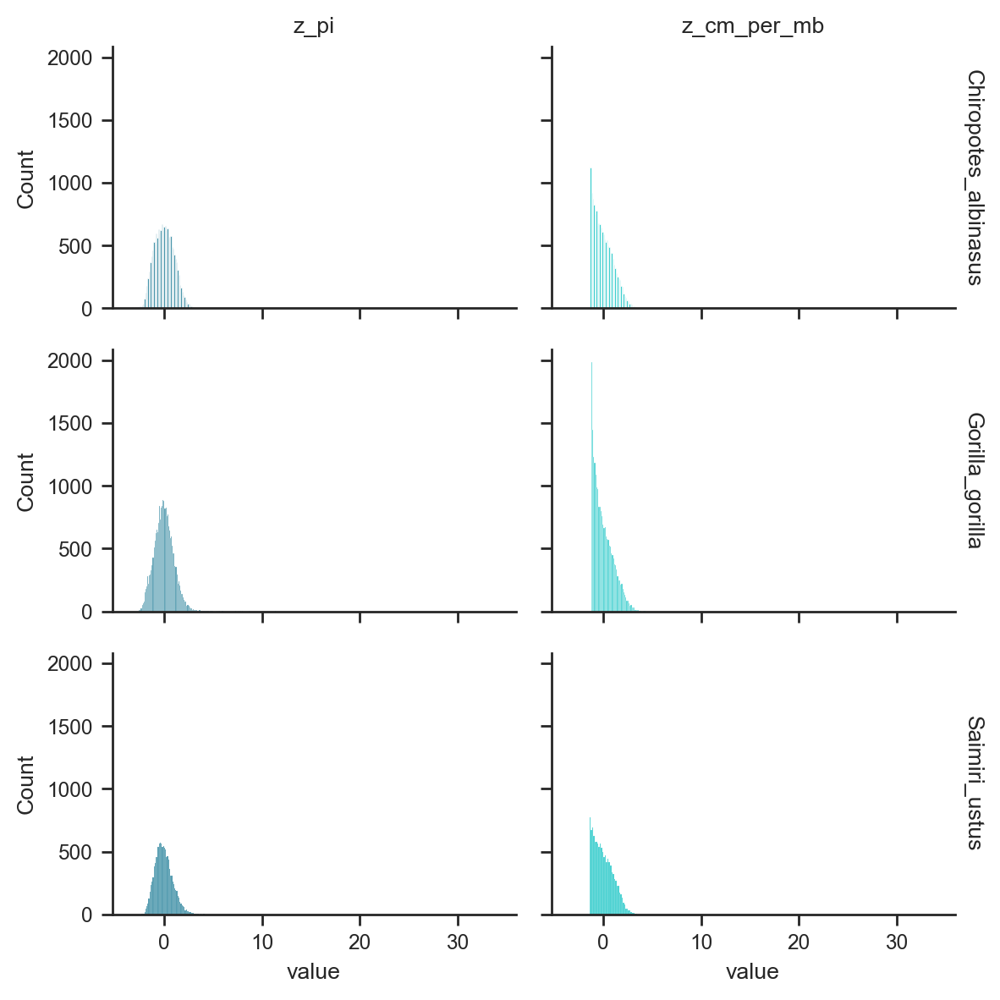

In [12]:
plot_df = data.loc[data.full_species.isin(selected_groups)].melt(id_vars='full_species', value_vars=['z_pi', 'z_cm_per_mb'])
g = sns.FacetGrid(plot_df, col="variable", row="full_species", hue="variable", margin_titles=True, height=2, aspect=1.5)
g.map_dataframe(sns.histplot, x="value")
g.set_titles(col_template="{col_name}", row_template="{row_name}")
for ax in g.axes.flat:
    title = ax.get_title()
    ax.set_title(title, rotation=0)
plt.tight_layout()

In [13]:
le = LabelEncoder()
species = le.fit_transform(data['full_species'])
pi = data['z_pi'].values
recombinationrate = data['z_cm_per_mb'].values

unique_species = pd.unique(le.inverse_transform(species))
ne = data[['full_species', 'z_ne']].drop_duplicates().z_ne

In [14]:
# population_idx = 
# background_pi = 
# admixture_prop = 

# population_label = 
# dist_from_hybzone = 

# Observations

In [15]:
window_y_values = pi
window_x_values = recombinationrate
global_group_names = unique_species
global_group_indices = species
global_group_values = ne

assert len(global_group_names) == len(global_group_values)
assert len(window_y_values) == len(window_x_values)
assert len(window_x_values) == len(global_group_indices)

# Hierarchical model

In [16]:
model_hierarchical = pm.Model(coords = {"global_group": global_group_names,
                           "obs_id": np.arange(len(window_x_values))})
non_centered = True

with model_hierarchical:
    # data
    window_dependent = pm.ConstantData('window_dependent', window_x_values, dims='obs_id')
    window_independent = pm.ConstantData('window_independent', window_y_values, dims='obs_id')
    global_group_member = pm.ConstantData('global_group_member', species, dims='obs_id')
    global_dependent =  pm.ConstantData('global_dependent', global_group_values, dims='global_group')

    # hyperprior on window_independent ~ window_dependent intercept prior
    hyp_inter_inter = pm.Normal("hyp_inter_inter", mu=0, sigma=1)
    hyp_inter_slope = pm.Normal("hyp_inter_slope", mu=0, sigma=1)
    
    # hyperprior on window_independent ~ window_dependent slope prior
    hyp_slope_inter = pm.Normal("hyp_slope_inter", mu=0, sigma=1)
    hyp_slope_slope = pm.Normal("hyp_slope_slope", mu=0, sigma=1)

    # prior on residual variation on global_group intercepts
    group_inter_residual = pm.Normal("group_inter_residual", 0, sigma=1, dims="global_group")
    
    # prior on residual variation on global_group slopes
    group_slope_residual = pm.Normal("group_slope_residual", 0, sigma=1, dims="global_group")

    # prior on window_independent ~ window_dependent intercept for each global_group
    mu_inter = hyp_inter_inter + hyp_inter_slope * global_dependent
    sigma_inter = pm.Exponential("sigma_inter", 1)
    group_inter = pm.Deterministic("group_inter", mu_inter + group_inter_residual * sigma_inter, dims="global_group")

    # prior on window_independent ~ window_dependent slope for each global_group
    mu_slope = hyp_slope_inter + hyp_slope_slope * global_dependent
    sigma_slope = pm.Exponential("sigma_slope", 1)
    group_slope = pm.Deterministic("group_slope", mu_slope + group_slope_residual * sigma_slope, dims="global_group")
        
    # prior window_independent ~ window_dependent slope for each global_group
    mu_window_independent = group_inter[global_group_member] + group_slope[global_group_member] * window_dependent
    sigma_window_independent = pm.Exponential("sigma_window_independent", 0.01)

    # prior
    WindowIndependent = pm.Normal("Independent", mu=mu_window_independent, sigma=sigma_window_independent, observed=window_independent, dims="obs_id")

In [17]:
%%capture
fig, ax = plt.subplots()
g = pm.model_to_graphviz(model_hierarchical)
g.graph_attr.update(size="10,10")

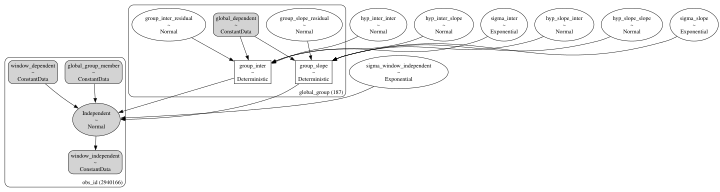

In [18]:
g

## Prior predictive checks

In [19]:
with model_hierarchical:
    idata_hierarchical = pm.sample_prior_predictive()

Sampling: [Independent, group_inter_residual, group_slope_residual, hyp_inter_inter, hyp_inter_slope, hyp_slope_inter, hyp_slope_slope, sigma_inter, sigma_slope, sigma_window_independent]


In [20]:
idata_hierarchical

Inference data with groups:
	> prior
	> prior_predictive
	> observed_data
	> constant_data

In [21]:
prior = idata_hierarchical.prior.squeeze(drop=True)
prior

<xarray.Dataset>
Dimensions:                   (draw: 500, global_group: 187)
Coordinates:
  * draw                      (draw) int64 0 1 2 3 4 5 ... 495 496 497 498 499
  * global_group              (global_group) <U28 'Allenopithecus_nigroviridi...
Data variables:
    hyp_inter_inter           (draw) float64 1.063 0.7278 ... 0.2406 -0.3017
    sigma_window_independent  (draw) float64 107.4 249.9 140.8 ... 5.291 293.3
    hyp_inter_slope           (draw) float64 -0.1979 -0.1542 ... -1.009 -1.345
    group_slope               (draw, global_group) float64 -0.06882 ... -0.6412
    hyp_slope_inter           (draw) float64 1.072 -0.5021 ... 0.7031 -0.0428
    group_slope_residual      (draw, global_group) float64 -1.93 ... -0.5886
    hyp_slope_slope           (draw) float64 -0.001598 -0.8686 ... -0.4202
    group_inter               (draw, global_group) float64 1.766 ... -0.38
    sigma_inter               (draw) float64 1.004 0.7136 ... 0.2878 0.7486
    sigma_slope               (draw) float64 0.5915 0.01387 ... 0.4048 1.071
    group_inter_residual      (draw, global_group) float64 0.6356 ... -0.2407
Attributes:
    created_at:                 2024-02-27T07:13:28.834968
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.10.0

# not sure if this makes any sense...

In [22]:
# xr.concat((prior["sigma_inter"], prior["sigma_slope"]), dim="global_group").rename(
#     "unique_species"
# ).assign_coords(global_group=selected_groups).plot.scatter(
#     x="global_group", y="species", edgecolors="none"
# );

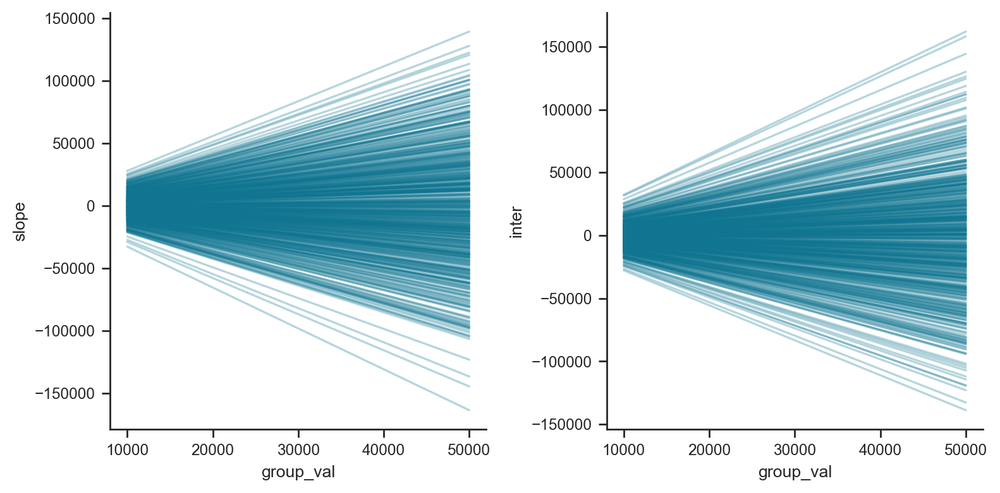

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

group_val = xr.DataArray(np.linspace(10000, 50000, 200), dims=["plot_dim"])
prior = idata_hierarchical.prior

slope = prior["hyp_slope_inter"] + prior["hyp_slope_slope"] * group_val
ax1.plot(group_val, slope.stack(sample=("chain", "draw")), c="C0", alpha=0.3)
ax1.set_xlabel("group_val")
ax1.set_ylabel("slope") 
inter = prior["hyp_inter_inter"] + prior["hyp_slope_inter"] * group_val
ax2.plot(group_val, inter.stack(sample=("chain", "draw")), c="C0", alpha=0.3)
ax2.set_xlabel("group_val")
ax2.set_ylabel("inter")
plt.tight_layout()

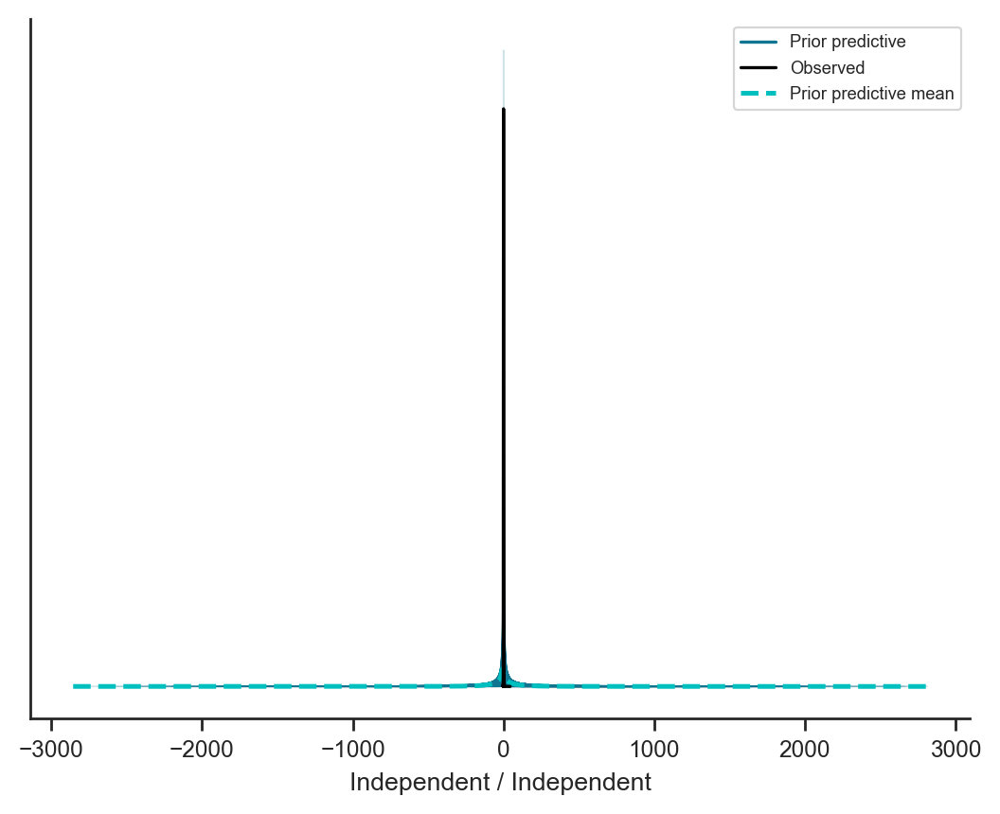

In [24]:
az.plot_ppc(idata_hierarchical, group='prior') ;

In [25]:
idata_hierarchical

Inference data with groups:
	> prior
	> prior_predictive
	> observed_data
	> constant_data

## Model trace

In [26]:
use_cached = True

trace_file = 'model_hierarchical.nc'
if use_cached and os.path.exists(trace_file):
    with model_hierarchical:
         idata_hierarchical = az.from_netcdf(trace_file)
else:
    with model_hierarchical:
        idata_hierarchical = pm.sample(#1000, 
                          target_accept=0.95, 
                          return_inferencedata=True,
                          progressbar=True, cores=8, chains=8)
        idata_hierarchical.to_netcdf(trace_file)

## Trace diagnostics

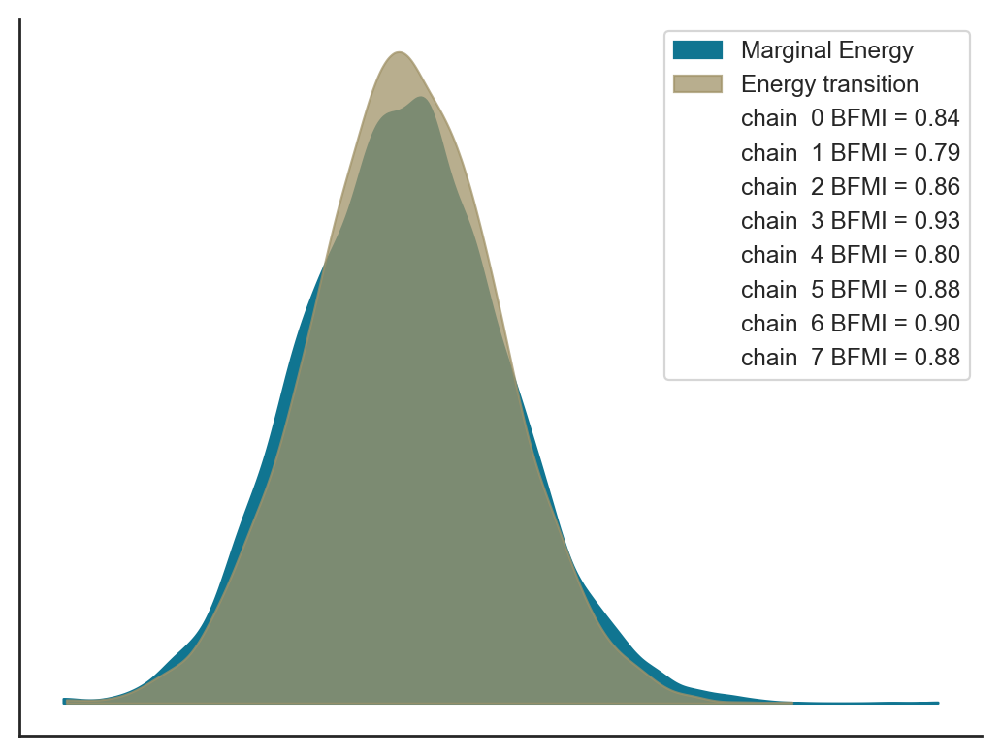

In [27]:
az.plot_energy(idata_hierarchical);

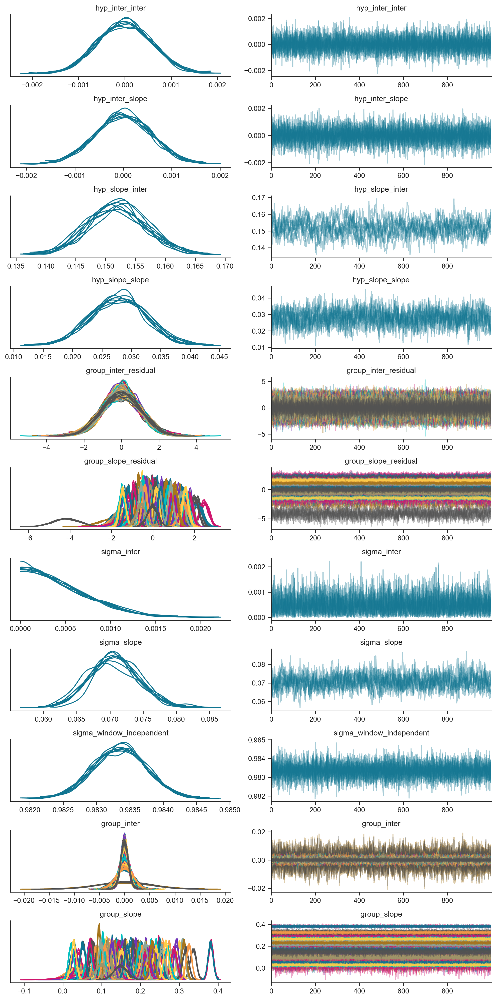

In [31]:
az.plot_trace(idata_hierarchical,
    # var_names=[],
    compact=True,
    figsize=(10, 20),
    chain_prop={"ls": "-"},
             )
plt.tight_layout()

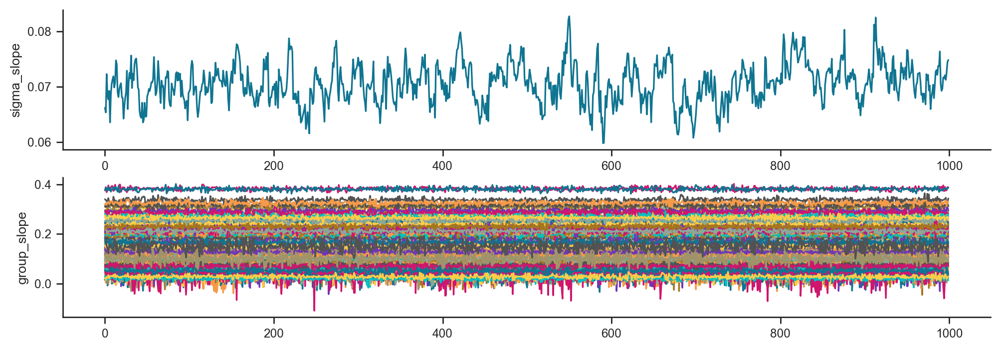

In [34]:
fig, axs = plt.subplots(nrows=2, figsize=(12,  4))
axs[0].plot(idata_hierarchical.posterior.sel(chain=0)["sigma_slope"])
axs[0].set(ylabel="sigma_slope")
axs[1].plot(idata_hierarchical.posterior.sel(chain=0)["group_slope"])
axs[1].set(ylabel="group_slope");

Text(0.5, 1.0, 'Chiropotes_albinasus')

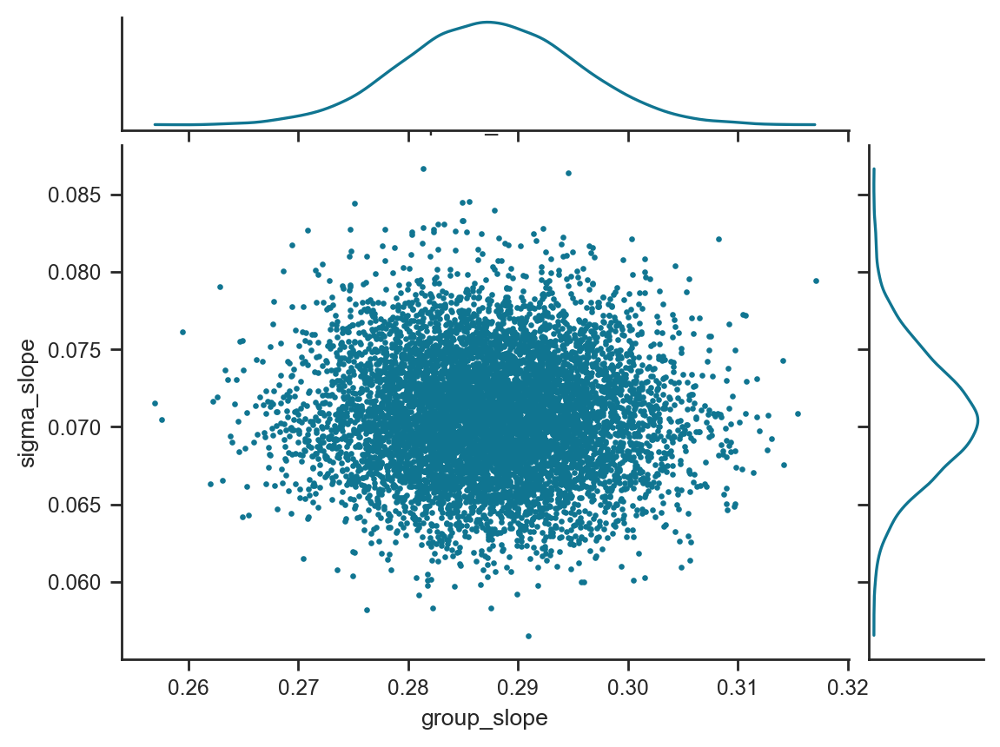

In [44]:
ax = az.plot_pair(
    idata_hierarchical,
    var_names=["group_slope", "sigma_slope"],
    coords=dict(global_group=selected_groups[1]),
    marginals=True,
    #marginal_kwargs={"kind": "hist"},
)
ax[1, 0].set_title(selected_groups[1])

## Posterior predictive checks

In [ ]:
with model_hierarchical:
    idata_hierarchical.extend(pm.sample_posterior_predictive(idata_hierarchical))

# # thin a sampled inferencedata by keeping 1 out of every 5 draws before passing it to sample_posterior_predictive
# thinned_idat = idat.sel(draw=slice(None, None, 5))
# with model_hierarchical:
#     idata_hierarchical.extend(pm.sample_posterior_predictive(thinned_idata_hierarchical))

# # generate 5 posterior predictive samples per posterior sample
# expanded_data = idata_hierarchical.posterior.expand_dims(pred_id=5)
# with model_hierarchical:
#     idata_hierarchical.extend(pm.sample_posterior_predictive(expanded_data))

Sampling: [Independent]


In [ ]:
idata_hierarchical

In [ ]:
az.summary(idata_hierarchical, round_to=2)

In [ ]:
post_mean = idata_hierarchical.posterior.mean(dim=("chain", "draw"))

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

group_val = xr.DataArray(np.linspace(10000, 50000, 200), dims=["plot_dim"])
posterior = idata_hierarchical.posterior

slope = posterior["hyp_slope_inter"] + posterior["hyp_slope_slope"] * group_val
ax1.plot(group_val, slope.stack(sample=("chain", "draw")), c="C0", alpha=0.01)
ax1.plot(group_val, post_mean["hyp_slope_inter"] + post_mean["hyp_slope_slope"] * group_val, c="C2")
ax1.set_xlabel("group_val")
ax1.set_ylabel("slope") 
inter = posterior["hyp_inter_inter"] + posterior["hyp_slope_inter"] * group_val
ax2.plot(group_val, inter.stack(sample=("chain", "draw")), c="C0", alpha=0.01)
ax2.plot(group_val, post_mean["hyp_inter_inter"] + post_mean["hyp_slope_inter"] * group_val, c="C2")
ax2.set_xlabel("group_val")
ax2.set_ylabel("intercept")
plt.tight_layout()

In [ ]:
ax = pm.plot_forest(
    idata_hierarchical,
#    var_names=["group_slope", "hyp_slope_slope", "hyp_slope_inter"],
    figsize=(6, 6),
    combined=True,
    r_hat=True,
#    labeller=az.labels.NoVarLabeller(),
)
#ax[0].set_ylabel("alpha")

In [ ]:
pm.plot_posterior(idata_hierarchical, var_names=["hyp_slope_slope", "hyp_slope_inter"], figsize=(8, 3));

In [ ]:
az.plot_dist_comparison(idata_hierarchical, var_names=["group_slope_slope", "group_slope_inter"], 
#                        coords={"global_group" : ['Macaca_arctoides', 'Macaca_cyclopis']},
                        figsize=(8, 6))
plt.tight_layout()

In [ ]:
obs_group = idata_hierarchical.posterior["global_group"][idata_hierarchical.constant_data["global_group_member"]]
_idata = idata_hierarchical.assign_coords(obs_id=obs_group, groups="observed_vars")
#_idata = idata.assign_coords(obs_id=obs_group)
az.plot_ppc(_idata, group='posterior', 
            coords={'obs_id': selected_groups}, 
            flatten=[], figsize=(9, 4)) ;

In [ ]:
# az.plot_ppc(_idata, group='posterior', flatten=[], figsize=(15, 10))
# plt.gca().legend(bbox_to_anchor=(1.1, 1.05))
# plt.tight_layout()

In [ ]:
az.plot_bpv(idata_hierarchical) ;

In [ ]:
az.plot_bpv(idata_hierarchical, kind="p_value") ;

In [ ]:
az.plot_bpv(idata_hierarchical, kind="t_stat", t_stat=lambda x:np.percentile(x, q=50, axis=-1)) ;

# Model with independent regressions

In [ ]:
model_parallel = pm.Model(coords = {"global_group": global_group_names,
                           "obs_id": np.arange(len(window_x_values))})
non_centered = True

with model_parallel:
    
    window_dependent = pm.ConstantData('window_dependent', window_x_values, dims='obs_id')
    window_independent = pm.ConstantData('window_independent', window_y_values, dims='obs_id')
    global_group_member = pm.ConstantData('global_group_member', species, dims='obs_id')
    # global_dependent =  pm.ConstantData('global_dependent', global_group_values, dims='global_group')

    # hyperprior on window_independent ~ window_dependent intercept prior
    hyp_inter_inter = pm.Normal("hyp_inter_inter", mu=0, sigma=1)
    # hyp_inter_slope = pm.Normal("hyp_inter_slope", mu=0, sigma=1)
    
    # hyperprior on window_independent ~ window_dependent slope prior
    # hyp_slope_inter = pm.Normal("hyp_slope_inter", mu=0, sigma=1)
    hyp_slope_slope = pm.Normal("hyp_slope_slope", mu=0, sigma=1)

    # prior on residual variation on global_group intercepts
    group_inter_residual = pm.Normal("group_inter_residual", 0, sigma=1, dims="global_group")
    
    # prior on residual variation on global_group slopes
    group_slope_residual = pm.Normal("group_slope_residual", 0, sigma=1, dims="global_group")

    # prior on window_independent ~ window_dependent intercept for each global_group
    # mu_inter = hyp_inter_inter + hyp_inter_slope * global_dependent
    mu_inter = hyp_inter_inter 
    sigma_inter = pm.Exponential("sigma_inter", 1)
    group_inter = pm.Deterministic("group_inter", mu_inter + group_inter_residual * sigma_inter, dims="global_group")

    # prior on window_independent ~ window_dependent slope for each global_group
    # mu_slope = hyp_slope_inter + hyp_slope_slope * global_dependent
    mu_slope = hyp_slope_slope
    sigma_slope = pm.Exponential("sigma_slope", 1)
    group_slope = pm.Deterministic("group_slope", mu_slope + group_slope_residual * sigma_slope, dims="global_group")
        
    # prior window_independent ~ window_dependent slope for each global_group
    mu_window_independent = group_inter[global_group_member] + group_slope[global_group_member] * window_dependent
    sigma_window_independent = pm.Exponential("sigma_window_independent", 0.01)

    # prior
    WindowIndependent = pm.Normal("Independent", mu=mu_window_independent, sigma=sigma_window_independent, observed=window_independent, dims="obs_id")

In [ ]:
%%capture
fig, ax = plt.subplots()
g = pm.model_to_graphviz(model_parallel)
g.graph_attr.update(size="10,10")

In [ ]:
g

## Prior predictive checks

In [ ]:
with model_parallel:
    idata_parallel = pm.sample_prior_predictive()

In [ ]:
az.plot_ppc(idata_parallel, group='prior') ;

In [ ]:
idata_parallel

## Model trace

In [ ]:
use_cached = False

trace_file = 'model_parallel.nc'
if use_cached and os.path.exists(trace_file):
    with model_parallel:
         idata_parallel = az.from_netcdf(trace_file)
else:
    with model_parallel:
        idata_parallel = pm.sample(#1000, 
                          target_accept=0.95, 
                          return_inferencedata=True,
                          progressbar=True, cores=8, chains=8)
        idata_parallel.to_netcdf(trace_file)

## Trace diagnostics

In [ ]:
az.plot_energy(idata_parallel);

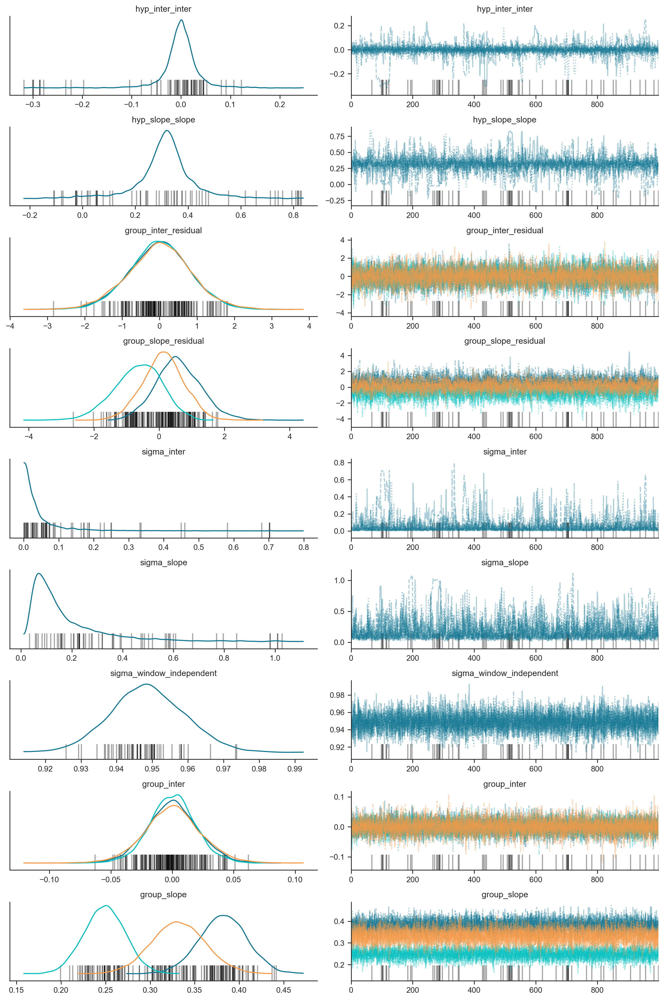

In [42]:
az.plot_trace(idata_parallel, combined=True)
plt.tight_layout()

## Posterior predictive checks

In [43]:
with model_parallel:
    idata_parallel.extend(pm.sample_posterior_predictive(idata_parallel))

# # thin a sampled inferencedata by keeping 1 out of every 5 draws before passing it to sample_posterior_predictive
# thinned_idat = idat.sel(draw=slice(None, None, 5))
# with model_parallel:
#     idata_parallel.extend(pm.sample_posterior_predictive(thinned_idata_parallel))

# # generate 5 posterior predictive samples per posterior sample
# expanded_data = idata_parallel.posterior.expand_dims(pred_id=5)
# with model_parallel:
#     idata_parallel.extend(pm.sample_posterior_predictive(expanded_data))

Sampling: [Independent]


In [44]:
idata_parallel

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data
	> constant_data

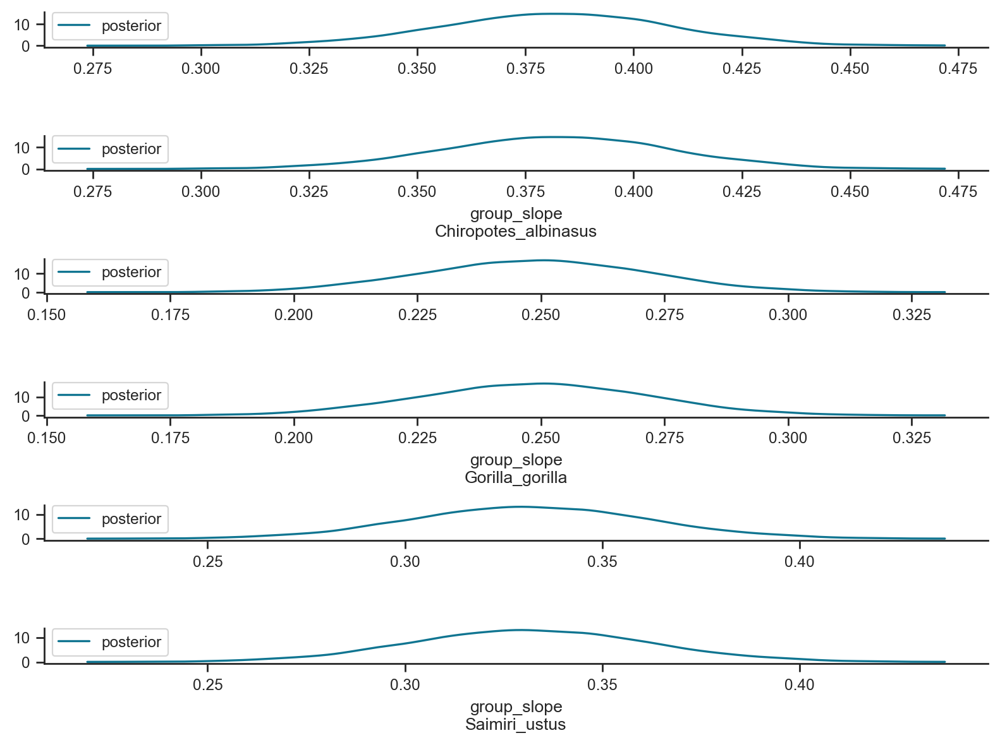

In [45]:
az.plot_dist_comparison(idata_parallel, var_names=["group_slope"], 
#                        coords={"global_group" : ['Macaca_arctoides', 'Macaca_cyclopis']},
                        figsize=(8, 6))
plt.tight_layout()

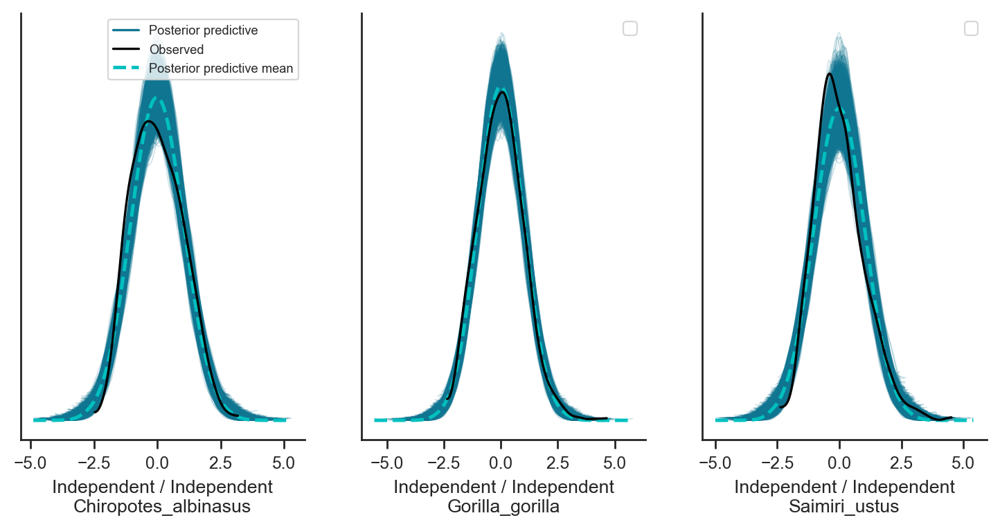

In [46]:
obs_group = idata_parallel.posterior["global_group"][idata_parallel.constant_data["global_group_member"]]
_idata = idata_parallel.assign_coords(obs_id=obs_group, groups="observed_vars")
#_idata = idata.assign_coords(obs_id=obs_group)
az.plot_ppc(_idata, group='posterior',
            # coords={'obs_id': ['Macaca_arctoides', 'Macaca_cyclopis']}, 
            flatten=[], figsize=(9, 4)) ;

In [47]:
# az.plot_ppc(_idata, group='posterior', flatten=[], figsize=(15, 10))
# plt.gca().legend(bbox_to_anchor=(1.1, 1.05))
# plt.tight_layout()

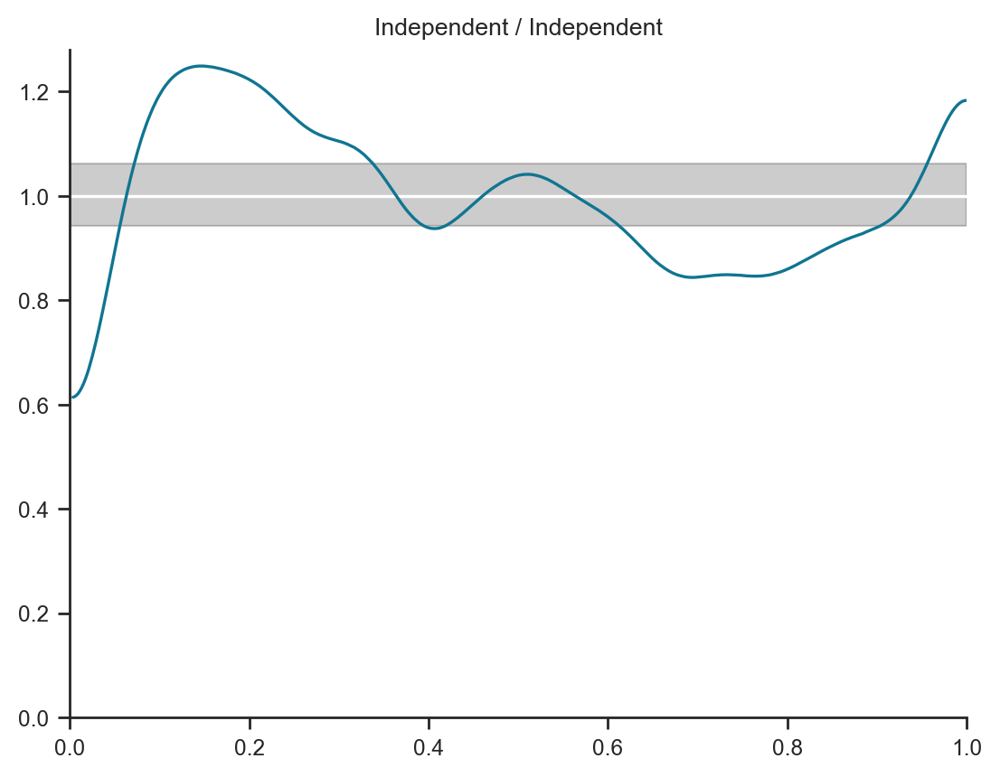

In [48]:
az.plot_bpv(idata_parallel) ;

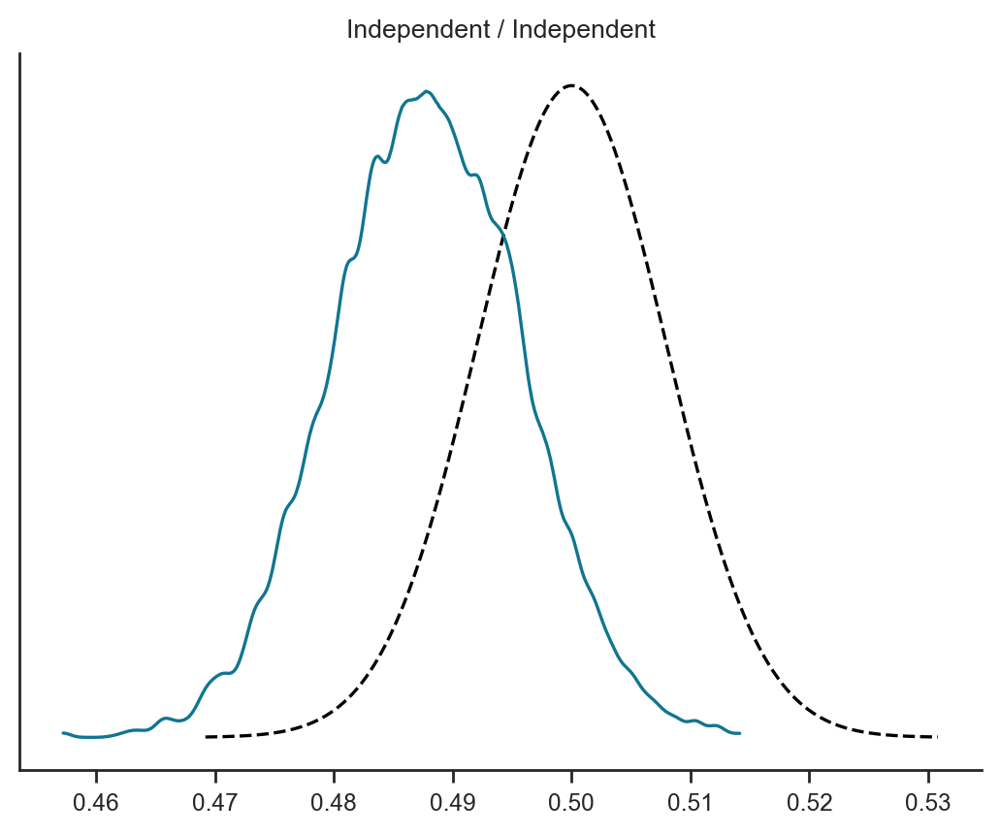

In [49]:
az.plot_bpv(idata_parallel, kind="p_value") ;

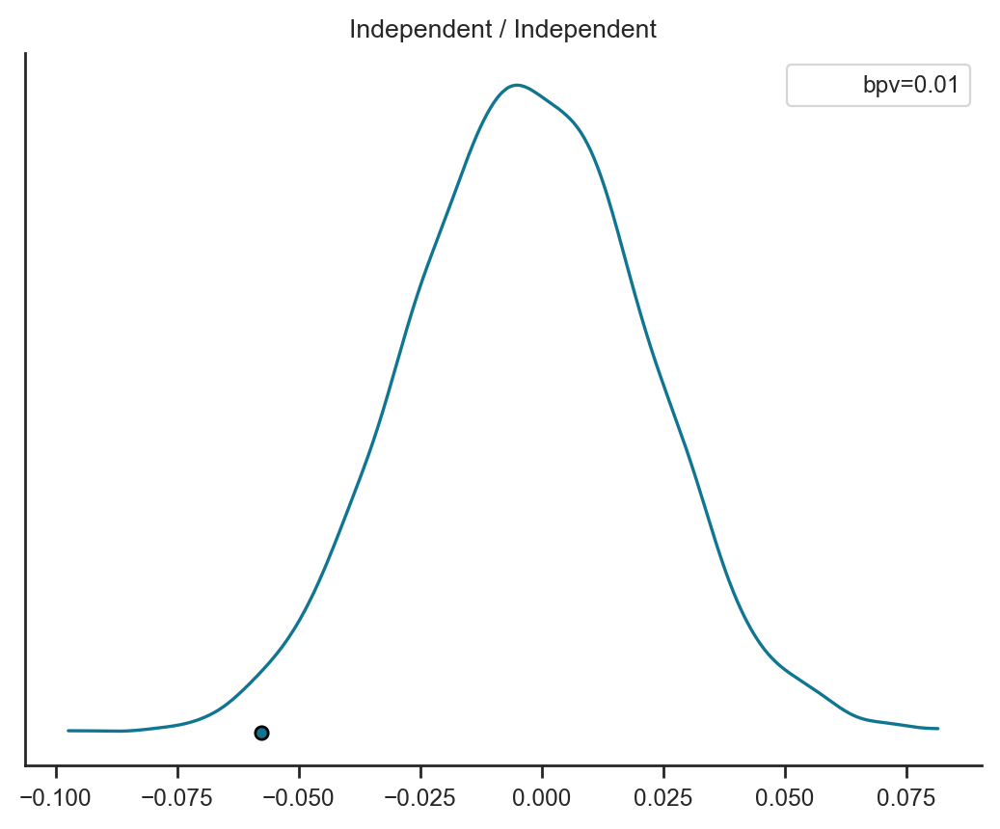

In [50]:
az.plot_bpv(idata_parallel, kind="t_stat", t_stat=lambda x:np.percentile(x, q=50, axis=-1)) ;

# Model comparison

In [51]:
with model_hierarchical:
    pm.compute_log_likelihood(idata_hierarchical)

In [52]:
with model_parallel:
    pm.compute_log_likelihood(idata_parallel)

In [53]:
loo_hierarchical = az.loo(idata_hierarchical)
loo_hierarchical

Computed from 8000 posterior samples and 3981 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -5442.26    49.87
p_loo        6.86        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.5]   (good)     3981  100.0%
 (0.5, 0.7]   (ok)          0    0.0%
   (0.7, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

In [54]:
loo_parallel = az.loo(idata_parallel)
loo_parallel

Computed from 8000 posterior samples and 3981 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -5441.31    49.86
p_loo        5.91        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.5]   (good)     3981  100.0%
 (0.5, 0.7]   (ok)          0    0.0%
   (0.7, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

ArviZ includes two convenience functions to help compare LOO for different models. The first of these functions is compare, which computes LOO (or WAIC) from a set of traces and models and returns a DataFrame.

In [55]:
# these should ofcaues be different models...
loo_compare = az.compare({"hierarchical": idata_hierarchical, 
                          "parallel": idata_parallel})
loo_compare

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
parallel,0,-5441.307888,5.908879,0.000000,1.0,49.861601,0.00000,False,log
hierarchical,1,-5442.258210,6.856368,0.950322,0.0,49.873923,0.26332,False,log


We have many columns, so let’s check out their meaning one by one:

1. The index is the names of the models taken from the keys of the dictionary passed to compare(.).
2. rank, the ranking of the models starting from 0 (best model) to the number of models.
3. loo, the values of LOO (or WAIC). The DataFrame is always sorted from best LOO/WAIC to worst.
4. p_loo, the value of the penalization term. We can roughly think of this value as the estimated effective number of parameters (but do not take that too seriously).
5. d_loo, the relative difference between the value of LOO/WAIC for the top-ranked model and the value of LOO/WAIC for each model. For this reason we will always get a value of 0 for the first model.
6. weight, the weights assigned to each model. These weights can be loosely interpreted as the probability of each model being true (among the compared models) given the data.
se, the standard error for the LOO/WAIC computations. The standard error can be useful to assess the uncertainty of the LOO/WAIC estimates. By default these errors are computed using stacking.
7. dse, the standard errors of the difference between two values of LOO/WAIC. The same way that we can compute the standard error for each value of LOO/WAIC, we can compute the standard error of the differences between two values of LOO/WAIC. Notice that both quantities are not necessarily the same, the reason is that the uncertainty about LOO/WAIC is correlated between models. This quantity is always 0 for the top-ranked model.
8. warning, If True the computation of LOO/WAIC may not be reliable.
9. loo_scale, the scale of the reported values. The default is the log scale as previously mentioned. Other options are deviance – this is the log-score multiplied by -2 (this reverts the order: a lower LOO/WAIC will be better) – and negative-log – this is the log-score multiplied by -1 (as with the deviance scale, a lower value is better).

The second convenience function takes the output of compare and produces a summary plot in the style of the one used in the book Statistical Rethinking by Richard McElreath (check also this port of the examples in the book to PyMC).

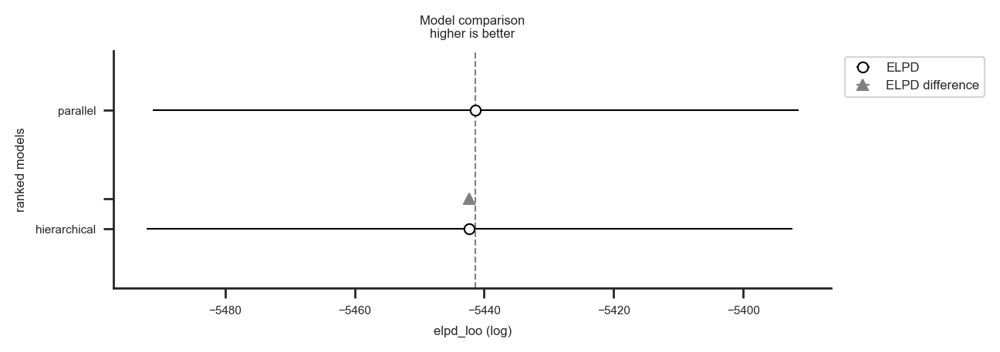

In [56]:
az.plot_compare(loo_compare, insample_dev=False);

The empty circle represents the values of LOO and the black error bars associated with them are the values of the standard deviation of LOO.

The value of the highest LOO, i.e the best estimated model, is also indicated with a vertical dashed grey line to ease comparison with other LOO values.

For all models except the top-ranked one we also get a triangle indicating the value of the difference of WAIC between that model and the top model and a grey error bar indicating the standard error of the differences between the top-ranked WAIC and WAIC for each model.

**Interpretation**

Though we might expect the hierarchical model to outperform a complete pooling model, there is little to choose between the models in this case, given that both models gives very similar values of the information criteria. This is more clearly appreciated when we take into account the uncertainty (in terms of standard errors) of LOO and WAIC.

[https://www.pymc.io/projects/docs/en/stable/learn/core_notebooks/model_comparison.html](https://www.pymc.io/projects/docs/en/stable/learn/core_notebooks/model_comparison.html)

## Inference

In [110]:
idata_hierarchical.posterior.to_dataframe().head()

hyp_inter_inter  hyp_inter_slope  \
chain draw global_group                                             
0     0    Chiropotes_albinasus        -0.498249        -0.757592   
           Rhinopithecus_bieti         -0.498249        -0.757592   
           Saimiri_ustus               -0.498249        -0.757592   
      1    Chiropotes_albinasus        -0.498249        -0.757592   
           Rhinopithecus_bieti         -0.498249        -0.757592   

                                 hyp_slope_inter  hyp_slope_slope  \
chain draw global_group                                             
0     0    Chiropotes_albinasus         0.382371         0.124617   
           Rhinopithecus_bieti          0.382371         0.124617   
           Saimiri_ustus                0.382371         0.124617   
      1    Chiropotes_albinasus         0.382371         0.124617   
           Rhinopithecus_bieti          0.382371         0.124617   

                                 group_inter_residual  group_slope_residual  \
chain draw global_group                                                       
0     0    Chiropotes_albinasus              0.834133             -1.247222   
           Rhinopithecus_bieti              -0.119798             -1.287705   
           Saimiri_ustus                    -0.036103             -0.384177   
      1    Chiropotes_albinasus              0.834133             -1.247222   
           Rhinopithecus_bieti              -0.119798             -1.287705   

                                 sigma_inter  sigma_slope  \
chain draw global_group                                     
0     0    Chiropotes_albinasus     1.723389     0.161513   
           Rhinopithecus_bieti      1.723389     0.161513   
           Saimiri_ustus            1.723389     0.161513   
      1    Chiropotes_albinasus     1.723389     0.161513   
           Rhinopithecus_bieti      1.723389     0.161513   

                                 sigma_window_independent  group_inter  \
chain draw global_group                                                  
0     0    Chiropotes_albinasus                  0.978168     0.012412   
           Rhinopithecus_bieti                   0.978168    -0.029836   
           Saimiri_ustus                         0.978168    -0.003285   
      1    Chiropotes_albinasus                  0.978168     0.012412   
           Rhinopithecus_bieti                   0.978168    -0.029836   

                                 group_slope  
chain draw global_group                       
0     0    Chiropotes_albinasus      0.33339  
           Rhinopithecus_bieti       0.06338  
           Saimiri_ustus             0.22867  
      1    Chiropotes_albinasus      0.33339  
           Rhinopithecus_bieti       0.06338

In [111]:
az.extract(idata_hierarchical, num_samples=20)

<xarray.Dataset>
Dimensions:                   (sample: 20, global_group: 3)
Coordinates:
  * global_group              (global_group) <U20 'Chiropotes_albinasus' ... ...
  * sample                    (sample) object MultiIndex
  * chain                     (sample) int64 0 5 4 4 5 1 4 3 ... 5 7 4 5 5 2 1 2
  * draw                      (sample) int64 821 277 381 358 ... 16 965 854 741
Data variables:
    hyp_inter_inter           (sample) float64 0.01154 -0.03976 ... 0.3784
    hyp_inter_slope           (sample) float64 -0.02637 -0.06057 ... -0.05401
    hyp_slope_inter           (sample) float64 -0.1592 0.23 ... 0.329 0.1635
    hyp_slope_slope           (sample) float64 -0.1095 0.03098 ... -0.05797
    group_inter_residual      (global_group, sample) float64 0.47 ... -0.6346
    group_slope_residual      (global_group, sample) float64 0.796 ... 0.5763
    sigma_inter               (sample) float64 0.02355 0.3331 ... 0.3656 0.7696
    sigma_slope               (sample) float64 0.7948 0.09525 ... 0.3228 0.1278
    sigma_window_independent  (sample) float64 0.9788 0.973 ... 0.9655 0.9772
    group_inter               (global_group, sample) float64 -0.009657 ... -0...
    group_slope               (global_group, sample) float64 0.3394 ... 0.2798
Attributes:
    created_at:                 2024-02-25T07:07:49.057547
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.10.0
    sampling_time:              65.65324187278748
    tuning_steps:               1000

In [112]:
data[['full_species', 'NE_MEAN']].drop_duplicates().set_index('full_species').loc[t.Species, 'NE_MEAN']

NameError: name 't' is not defined

In [ ]:
d = idata.posterior.mean(dim=['chain', 'draw'])
sns.barplot(data=pd.DataFrame(dict(x=d.Species, y=d.b)), x='x', y='y')

In [ ]:
idata.groups()

In [ ]:
sns.set_context('paper')
az.plot_bf(idata.posterior, var_name="h1") ;
#sns.despine()

In [ ]:
az.plot_forest(idata.posterior, var_names=['h0', 'h1']) ;

In [ ]:
az.plot_posterior(idata, var_names=['a', 'b'], figsize=(16, 15))
plt.tight_layout()

In [ ]:
az.plot_posterior(idata, var_names=['a', 'b'], combine_dims={'Species'}, figsize=(6, 5)) ;

In [ ]:
az.plot_forest(idata.posterior, var_names=['g0', 'g1', 'h0', 'h1'], ess=True, figsize=(6, 5)) ;

In [ ]:
az.plot_forest(idata.posterior, var_names=['b'], ess=True, figsize=(15, 100)) ;

In [ ]:
import arviz as az
import numpy as np
import timeit
import dask

from arviz.utils import conditional_jit, Dask

In [ ]:
# optional imports
from dask.distributed import Client
from dask.diagnostics import ResourceProfiler

from bokeh.resources import INLINE
import bokeh.io

bokeh.io.output_notebook(INLINE)

%reload_ext memory_profiler

> ResourceProfiler() and Client are optional. They are only used for the visualizing and profiling the dask enabled methods. ArviZ-Dask integration can be used without using these objects.

In [ ]:
client = Client(threads_per_worker=4, n_workers=1, memory_limit="1.2GB")
client

In [ ]:
array_size = 250_000_000

In [ ]:
%%memit 
data = np.random.randn(array_size)
np.var(data, ddof=1)
del data

In [ ]:
%memit data = dask.array.random.normal(size=array_size, chunks="auto")
data

In [ ]:
var = dask.array.var(data, ddof=1)
var.visualize()

In [ ]:
with ResourceProfiler(dt=0.25) as rprof:
    var.compute()

rprof.visualize();